# 引入必要库

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei'] 
plt.rcParams['axes.unicode_minus'] = False 

# 加载数据

In [2]:
daily_input_file = "basic_data/daily_data.parquet"
industry_input_file = "basic_data/industry.parquet"
st_input_file = "basic_data/st.parquet"
suspended_input_file = "basic_data/停牌.parquet"

daily_data = pd.read_parquet(daily_input_file)
industry_data = pd.read_parquet(industry_input_file)
st_data = pd.read_parquet(st_input_file)
suspended_data = pd.read_parquet(suspended_input_file)

print("daily_data shape:", daily_data.shape)
print("industry_data shape:", industry_data.shape)
print("st_data shape:", st_data.shape)
print("suspended_data shape:", suspended_data.shape)


daily_data shape: (8717164, 13)
industry_data shape: (9012858, 4)
st_data shape: (3159, 5370)
suspended_data shape: (8730456, 3)


In [3]:
# 数据概览
print("=== daily_data ===")
print("Index:", daily_data.index.names)
print("Columns:", daily_data.columns.tolist())
print("Date range:", daily_data.index.get_level_values(0).min(), "to", daily_data.index.get_level_values(0).max())
print("Unique stocks:", daily_data.index.get_level_values(1).nunique())
print()

print("=== industry_data ===")
print("Index:", industry_data.index.names)
print("Columns:", industry_data.columns.tolist())
print(industry_data.head(2))
print()

print("=== st_data ===")
print("Index type:", st_data.index.name)
print("Shape:", st_data.shape)
print("Sample:", st_data.iloc[:3, :3])
print()

print("=== suspended_data ===")
print("Columns:", suspended_data.columns.tolist())
print("Sample:", suspended_data.head())


=== daily_data ===
Index: ['DATE', 'CODE']
Columns: ['AVERAGE_PRICE', 'DY-ADJ_AF-CLOSE_PRICE_2', 'DY-ADJ_AF-HIGHEST_PRICE_2', 'DY-ADJ_AF-LOWEST_PRICE_2', 'DY-ADJ_AF-OPEN_PRICE_2', 'DY-ADJ_AF-TURNOVER_VOL', 'DY-BASIC-DEAL_AMOUNT', 'DY-BASIC-MARKET_VALUE', 'DY-BASIC-NEG_MARKET_VALUE', 'DY-BASIC-TURNOVER_RATE', 'DY-BASIC-TURNOVER_VALUE', 'DY-IND-CHG_STATUS', 'DY-IND-DEAL_VALUE']
Date range: 2010-01-04 to 2021-12-31
Unique stocks: 4687

=== industry_data ===
Index: ['CODE', 'DATE']
Columns: ['TYPE_ID', 'LEVEL1_NAME', 'LEVEL2_NAME', 'LEVEL3_NAME']
                        TYPE_ID LEVEL1_NAME LEVEL2_NAME LEVEL3_NAME
CODE   DATE                                                        
000001 20100104  DY010321330101        金融服务          银行          银行
       20100105  DY010321330101        金融服务          银行          银行

=== st_data ===
Index type: None
Shape: (3159, 5370)
Sample:          000001 000002 000003
20100104   None   None      T
20100105   None   None      T
20100106   None   None     


# 数据清洗与剔除

In [4]:

# 0. 先把 daily_data 日期索引统一为 datetime，并重命名索引
daily_data = daily_data.copy()
daily_data.index = pd.MultiIndex.from_arrays([
    pd.to_datetime(daily_data.index.get_level_values(0)),
    daily_data.index.get_level_values(1)
], names=['date', 'code'])

# 列重命名
daily_data = daily_data.rename(columns={
    'DY-ADJ_AF-OPEN_PRICE_2': 'open',
    'DY-ADJ_AF-HIGHEST_PRICE_2': 'high',
    'DY-ADJ_AF-LOWEST_PRICE_2': 'low',
    'DY-ADJ_AF-CLOSE_PRICE_2': 'close',
    'DY-BASIC-MARKET_VALUE': '市值'
})

# 1. 停牌数据对齐：
sp = suspended_data.copy()
sp.columns = ['code', 'date', 'is_suspended']  # 列名乱码，按顺序重命名
sp = sp.set_index(['date', 'code'])['is_suspended']

# 2. ST 数据对齐：
st = st_data.copy()
st.index = pd.to_datetime(st.index, format='%Y%m%d')
st_long = st.stack().reset_index()
st_long.columns = ['date', 'code', 'st_flag']
st_long['is_st'] = st_long['st_flag'].notna() 
st_long = st_long.set_index(['date', 'code'])['is_st']

# 3. 合并到主表
df = daily_data.copy()
df = df.join(sp, how='left')
df = df.join(st_long, how='left')

# 缺失值填充
df['is_suspended'] = df['is_suspended'].fillna(0).astype(bool)
df['is_st'] = df['is_st'].fillna(False)

# 4. 涨跌停判断：
# 用9.5%作为阈值
# 涨停：收益率>=+9.5% 且 收盘价等于最高价；跌停：收益率<=-9.5% 且 收盘价等于最低价
df = df.sort_index()
df['pre_close'] = df.groupby('code')['close'].shift(1)
df['ret'] = df['close'] / df['pre_close'] - 1

df['is_up_limit'] = (df['ret'] >= 0.095) & (df['close'] == df['high'])
df['is_down_limit'] = (df['ret'] <= -0.095) & (df['close'] == df['low'])
df['is_limit'] = df['is_up_limit'] | df['is_down_limit']

# 5. 上市天数计算（自然日）
first_trade = df.groupby(level=1).apply(lambda x: x.index.get_level_values(0).min())
df['first_trade_date'] = df.index.get_level_values(1).map(first_trade)
df['days_since_listing'] = (df.index.get_level_values(0) - df['first_trade_date']).dt.days

# 数据起始日就存在的股票，默认不是新股
data_start = df.index.get_level_values(0).min()
df.loc[df['first_trade_date'] == data_start, 'days_since_listing'] = 9999

# 6. 有效样本标记
df['valid'] = (
    (~df['is_limit']) &
    (~df['is_suspended']) &
    (~df['is_st']) &
    (df['days_since_listing'] >= 60)
)

# 7. 统计信息
print("=" * 40)
print("数据清洗统计")
print("=" * 40)
print(f"总记录数: {len(df):,}")
print(f"当日有效样本数: {df['valid'].sum():,}")
print(f"有效比例: {df['valid'].mean():.2%}")
print()

print("各剔除条件占比:")
print(f"  涨停:   {df['is_up_limit'].mean():.2%}")
print(f"  跌停:   {df['is_down_limit'].mean():.2%}")
print(f"  停牌:   {df['is_suspended'].mean():.2%}")
print(f"  ST:     {df['is_st'].mean():.2%}")
print(f"  新股(<60天): {(df['days_since_listing'] < 60).mean():.2%}")

C:\Users\HP\AppData\Local\Temp\ipykernel_14808\2029824624.py:37: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['is_st'] = df['is_st'].fillna(False)


数据清洗统计
总记录数: 8,717,164
当日有效样本数: 7,736,052
有效比例: 88.75%

各剔除条件占比:
  涨停:   1.54%
  跌停:   0.79%
  停牌:   4.70%
  ST:     3.85%
  新股(<60天): 1.35%



# 计算因子与收益率


In [5]:
df_reset = df.reset_index()

# 因子：5日价格动量 close_t0 / close_t-5 - 1
df_reset['factor'] = df_reset.groupby('code')['close'].transform(
    lambda x: x / x.shift(5) - 1
)

# 1. 先标记 t1 日有效性
df_reset['valid_t1'] = df_reset.groupby('code')['valid'].shift(-1)

# 2. 提取 open_t1 和 open_t2，同时把无效样本的价格清为 NaN
df_reset['open_t1'] = df_reset.groupby('code')['open'].shift(-1)
df_reset['open_t2'] = df_reset.groupby('code')['open'].shift(-2)
df_reset.loc[df_reset['valid_t1'] == False, ['open_t1', 'open_t2']] = np.nan

# 3. 计算收益率
df_reset['return'] = df_reset['open_t2'] / df_reset['open_t1'] - 1

df_reset['return'] = df_reset['return'].replace([np.inf, -np.inf], np.nan)

# 4. 排除 open_t1 或 open_t2 为 0/负值 的异常样本（避免 -100% 极端离群值）
df_reset.loc[(df_reset['open_t1'] <= 0) | (df_reset['open_t2'] <= 0), 'return'] = np.nan

# 恢复索引
df = df_reset.set_index(['date', 'code']).sort_index()

# 统计
print("=" * 40)
print("因子与收益率统计")
print("=" * 40)
print(f"总记录数: {len(df):,}")
print(f"t1 日有效样本数: {df['valid_t1'].sum():,}")
print(f"有效比例: {df['valid_t1'].mean():.2%}")
print()

# 因子和收益率的描述统计（仅有效样本）
valid_df = df_reset[df_reset['valid_t1'] == True]


def print_describe_pct(series, title):
    desc = series.describe()
    print(f"{title}描述统计:")
    for k, v in desc.items():
        if k == 'count':
            print(f"  {k:>6s}: {v:,.0f}")
        else:
            print(f"  {k:>6s}: {v*100:>10.2f}%")
    print()


print_describe_pct(valid_df['factor'], "有效样本中因子")
print_describe_pct(valid_df['return'], "有效样本中收益率")

因子与收益率统计
总记录数: 8,717,164
t1 日有效样本数: 7,734,536
有效比例: 88.78%

有效样本中因子描述统计:
   count: 7,727,082
    mean:       0.25%
     std:       6.89%
     min:     -64.37%
     25%:      -3.33%
     50%:       0.00%
     75%:       3.44%
     max:    1676.65%

有效样本中收益率描述统计:
   count: 7,703,846
    mean:      -0.02%
     std:       2.74%
     min:     -38.54%
     25%:      -1.43%
     50%:       0.00%
     75%:       1.39%
     max:      36.67%



由于数据第一天就存在的数据无法确定上市日期，所以暂时当做不是新股，但是这样会导致计算因子值时出现nan，因此因子统计总数小于收益率

# 因子标准化（Z-score标准化、rank标准化）

In [6]:
# 在每个交易日截面上，仅对 valid_t1=True 且 return 非 NaN 的样本标准化
df_reset = df.reset_index()
df_reset['valid_for_std'] = df_reset['valid_t1'] & df_reset['return'].notna()

# 屏蔽无效样本的因子值
df_reset['factor_masked'] = df_reset['factor'].where(df_reset['valid_for_std'])

# Z-Score 标准化：
df_reset['factor_zscore'] = df_reset.groupby('date')['factor_masked'].transform(
    lambda x: (x - x.mean()) / x.std()
)

# Rank 标准化：
def rank_standardize(x):
    ranks = x.rank()
    return (ranks - ranks.mean()) / ranks.std()

df_reset['factor_rank'] = df_reset.groupby('date')['factor_masked'].transform(rank_standardize)

# 恢复索引
df = df_reset.set_index(['date', 'code']).sort_index()

# 统计
print("=" * 40)
print("标准化后因子统计（仅有效样本）")
print("=" * 40)
valid_df = df_reset[df_reset['valid_for_std']]

for col, name in [('factor_zscore', 'Z-Score'), ('factor_rank', 'Rank')]:
    desc = valid_df[col].describe()
    print(f"\n{name}:")
    for k, v in desc.items():
        if k == 'count':
            print(f"  {k:>6s}: {v:,.0f}")
        else:
            print(f"  {k:>6s}: {v:>10.4f}")

标准化后因子统计（仅有效样本）

Z-Score:
   count: 7,696,478
    mean:    -0.0000
     std:     0.9998
     min:   -11.1758
     25%:    -0.5415
     50%:    -0.1010
     75%:     0.4140
     max:    47.6829

Rank:
   count: 7,696,478
    mean:     0.0000
     std:     0.9998
     min:    -1.7314
     25%:    -0.8658
     50%:     0.0000
     75%:     0.8658
     max:     1.7314


In [7]:
df_reset = df.reset_index()

# 1. 合并行业数据（一级行业）
if 'LEVEL1_NAME' not in df_reset.columns:
    print("正在合并行业数据...")
    ind = industry_data.reset_index()
    ind['DATE'] = pd.to_datetime(ind['DATE'], format='%Y%m%d')
    ind = ind.rename(columns={'CODE': 'code', 'DATE': 'date'})
    df_reset = df_reset.merge(
        ind[['date', 'code', 'LEVEL1_NAME']], 
        on=['date', 'code'], 
        how='left'
    )

# 2. 对数市值（排除 log(0)=-inf）
df_reset['log_mv'] = np.log(df_reset['市值'])
df_reset['log_mv'] = df_reset['log_mv'].replace([-np.inf, np.inf], np.nan)

# 3. 中性化函数（statsmodels OLS）
def neutralize_factor(df_sub, factor_col):
    """单个截面的市值+行业中性化，返回残差 Series"""
    mask = (
        df_sub[factor_col].notna() & 
        df_sub['log_mv'].notna() & 
        df_sub['LEVEL1_NAME'].notna()
    )
    valid = df_sub[mask].copy()
    
    n = len(valid)
    n_industries = valid['LEVEL1_NAME'].nunique()
    
    if n < 20 or n < n_industries + 2:
        return pd.Series(np.nan, index=df_sub.index)
    
    try:
        # 行业虚拟变量
        dummies = pd.get_dummies(valid['LEVEL1_NAME'], prefix='ind', drop_first=True)
        
        # 自变量
        X = pd.concat([valid[['log_mv']], dummies], axis=1)
        X = sm.add_constant(X, has_constant='add')
        y = valid[factor_col]
        
        # OLS 回归
        X = X.astype(float)
        y = y.astype(float)
        model = sm.OLS(y, X, missing='drop').fit()
        
        resid = pd.Series(np.nan, index=df_sub.index)
        resid.loc[valid.index] = model.resid
        return resid
        
    except Exception as e:
        print(f"  Warning: {df_sub['date'].iloc[0]} 回归失败: {e}")
        return pd.Series(np.nan, index=df_sub.index)

# 4. 执行中性化
print("正在进行市值+行业中性化...")
for col, out_col in [('factor_zscore', 'factor_zscore_neu'), ('factor_rank', 'factor_rank_neu')]:
    resid_list = []
    for date, group in df_reset.groupby('date'):
        resid = neutralize_factor(group, col)
        resid_list.append(resid)
    df_reset[out_col] = pd.concat(resid_list)
    print(f"  {out_col} 完成, 非NaN数: {df_reset[out_col].notna().sum():,}")

# 恢复索引
df = df_reset.set_index(['date', 'code']).sort_index()

# 5. 统计
print("\n" + "=" * 40)
print("中性化后因子统计（仅有效样本）")
print("=" * 40)
valid_df = df_reset[df_reset['valid_for_std']]

for col, name in [('factor_zscore_neu', 'Z-Score中性化'), ('factor_rank_neu', 'Rank中性化')]:
    desc = valid_df[col].describe()
    print(f"\n{name}:")
    for k, v in desc.items():
        if k == 'count':
            print(f"  {k:>6s}: {v:,.0f}")
        else:
            print(f"  {k:>6s}: {v:>10.4f}")

正在合并行业数据...
正在进行市值+行业中性化...
  factor_zscore_neu 完成, 非NaN数: 7,696,478
  factor_rank_neu 完成, 非NaN数: 7,696,478

中性化后因子统计（仅有效样本）

Z-Score中性化:
   count: 7,696,478
    mean:    -0.0000
     std:     0.9482
     min:   -11.2337
     25%:    -0.5012
     50%:    -0.0840
     75%:     0.3815
     max:    47.3185

Rank中性化:
   count: 7,696,478
    mean:    -0.0000
     std:     0.9356
     min:    -3.3883
     25%:    -0.7463
     50%:    -0.0042
     75%:     0.7421
     max:     3.2915


# 计算原始和和中性化后因子IC值（因子选择rank标准化）

In [8]:
df_reset = df.reset_index()

# 计算截面 Spearman IC
def calc_ic(group, factor_col):
    valid = group[group[factor_col].notna() & group['return'].notna()]
    if len(valid) < 10:
        return np.nan
    return valid[factor_col].corr(valid['return'], method='spearman')

# 分别计算两种因子的 IC 序列：Rank原始 和 Rank中性化
ic_results = {}
for col, name in [('factor_rank', 'Rank原始'), ('factor_rank_neu', 'Rank中性化')]:
    ic_series = df_reset.groupby('date').apply(lambda g: calc_ic(g, col))
    ic_results[name] = ic_series

# IC 统计检验
print("=" * 40)
print("IC 检验结果")
print("=" * 40)
for name, ic in ic_results.items():
    n = ic.notna().sum()
    ic_mean = ic.mean()
    ic_std = ic.std()
    ic_ir = ic_mean / ic_std
    ic_t = ic_mean / (ic_std / np.sqrt(n))
    
    print(f"\n{name}:")
    print(f"  样本数: {n:,}")
    print(f"  IC 均值: {ic_mean:>10.4f}")
    print(f"  IC 标准差: {ic_std:>10.4f}")
    print(f"  IR (均值/标准差): {ic_ir:>10.4f}")
    print(f"  t 统计量: {ic_t:>10.4f}")
    print(f"  年化IR (IR*sqrt(252)): {ic_ir * np.sqrt(252):>10.4f}")

# 保存 IC 序列到 df 用于后续画图
df_ic = pd.DataFrame(ic_results)
df_ic.index.name = 'date'
print("\nIC 序列已生成，可用于后续画图。")

C:\Users\HP\AppData\Local\Temp\ipykernel_14808\130630558.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ic_series = df_reset.groupby('date').apply(lambda g: calc_ic(g, col))


IC 检验结果

Rank原始:
  样本数: 2,910
  IC 均值:    -0.0580
  IC 标准差:     0.1429
  IR (均值/标准差):    -0.4059
  t 统计量:   -21.8981
  年化IR (IR*sqrt(252)):    -6.4441

Rank中性化:
  样本数: 2,910
  IC 均值:    -0.0575
  IC 标准差:     0.1134
  IR (均值/标准差):    -0.5070
  t 统计量:   -27.3482
  年化IR (IR*sqrt(252)):    -8.0479

IC 序列已生成，可用于后续画图。


C:\Users\HP\AppData\Local\Temp\ipykernel_14808\130630558.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ic_series = df_reset.groupby('date').apply(lambda g: calc_ic(g, col))


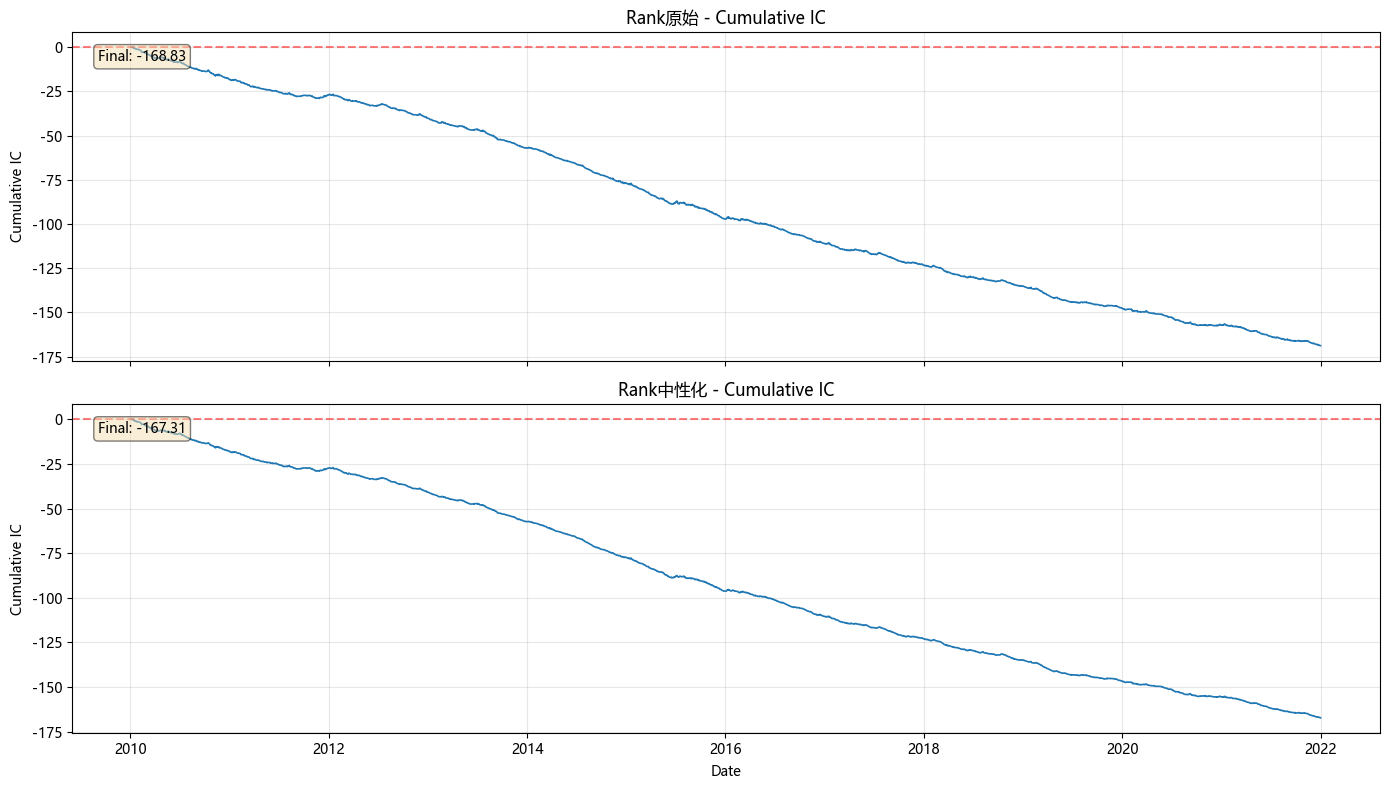

In [9]:
# Cumulative Sum IC 图
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for i, (name, ic) in enumerate(ic_results.items()):
    ax = axes[i]
    cum_ic = ic.fillna(0).cumsum()
    ax.plot(cum_ic.index, cum_ic.values, linewidth=1.2)
    ax.set_title(f'{name} - Cumulative IC', fontsize=12)
    ax.set_ylabel('Cumulative IC')
    ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
    ax.grid(True, alpha=0.3)
    
    final_val = cum_ic.iloc[-1]
    ax.text(0.02, 0.95, f'Final: {final_val:.2f}', transform=ax.transAxes,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()

# 保存图片（如需提交）
# fig.savefig('cumulative_ic.png', dpi=300, bbox_inches='tight')


IC检验显示因子值与收益负相关，应反向生成信号

# 分层回测（8层，等权 + 市值加权）

In [10]:
df_reset = df.reset_index()

def calc_stratified_returns(df_reset, factor_col, n_layers, weight_method='equal'):
    """计算分层每日收益，返回 DataFrame"""
    returns_list = []
    
    for date, group in df_reset.groupby('date'):
        valid = group[group[factor_col].notna() & group['return'].notna()].copy()
        if len(valid) < n_layers * 5:
            ret = pd.Series(np.nan, index=range(1, n_layers + 1))
            ret.name = date
            returns_list.append(ret)
            continue
        
        try:
            valid['layer'] = pd.qcut(valid[factor_col], q=n_layers, labels=False) + 1
        except ValueError:
            ret = pd.Series(np.nan, index=range(1, n_layers + 1))
            ret.name = date
            returns_list.append(ret)
            continue
        
        if weight_method == 'equal':
            ret = valid.groupby('layer')['return'].mean()
        else:
            def wmean(g):
                w = g['市值'].fillna(0)
                if w.sum() <= 0:
                    return np.nan
                return np.average(g['return'], weights=w)
            ret = valid.groupby('layer', group_keys=False).apply(wmean)
        
        ret = ret.reindex(range(1, n_layers + 1))
        ret.name = date
        returns_list.append(ret)
    
    return pd.DataFrame(returns_list)

def calc_metrics(nav):
    """从净值序列计算评价指标"""
    returns = nav.pct_change(fill_method=None).dropna()
    if len(returns) == 0 or returns.isna().all():
        return {}
    
    # 找第一个非NaN值作为起点
    first_valid = nav.dropna().iloc[0] if nav.notna().any() else np.nan
    last_valid = nav.dropna().iloc[-1] if nav.notna().any() else np.nan
    
    if pd.isna(first_valid) or pd.isna(last_valid) or first_valid == 0:
        ann_ret = np.nan
    else:
        ann_ret = (last_valid / first_valid) ** (252 / nav.notna().sum()) - 1
    
    ann_vol = returns.std() * np.sqrt(252)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else np.nan
    dd = 1 - nav / nav.cummax()
    max_dd = dd.max()
    
    return {
        '年化收益': ann_ret,
        '年化波动': ann_vol,
        '夏普比率': sharpe,
        '最大回撤': max_dd
    }

# 执行回测
configs = [
    ('factor_rank', 'Rank原始'),
    ('factor_rank_neu', 'Rank中性化')
]

all_results = {}
print("=" * 60)
print("分层回测执行中（8层，等权 + 市值加权）")
print("=" * 60)

for fcol, fname in configs:
    for wmethod, wname in [('equal', '等权'), ('mv', '市值加权')]:
        key = f"{fname}_{wname}"
        print(f"\n>>> 计算: {key}")
        
        layer_ret = calc_stratified_returns(df_reset, fcol, n_layers=8, weight_method=wmethod)
        
        # 累计净值（修复起点NaN问题：从第一个有效值开始归一化为1）
        nav = (1 + layer_ret).cumprod()
        for col in nav.columns:
            first_idx = nav[col].first_valid_index()
            if first_idx is not None:
                first_val = nav.loc[first_idx, col]
                if pd.notna(first_val) and abs(first_val) > 1e-12:
                    nav[col] = nav[col] / first_val
        
        nav.columns = [f'Layer_{c}' for c in nav.columns]
        
        # 多空组合（Layer_1 - Layer_8），IC为负，低因子值预期收益高
        long_short_ret = layer_ret[1] - layer_ret[8]
        long_short_nav = (1 + long_short_ret.fillna(0)).cumprod()
        # 归一化多空净值起点
        first_idx = long_short_nav.first_valid_index()
        if first_idx is not None:
            first_val = long_short_nav.loc[first_idx]
            if pd.notna(first_val) and abs(first_val) > 1e-12:
                long_short_nav = long_short_nav / first_val
        nav['Long_Short'] = long_short_nav
        
        all_results[key] = nav
        
        # 评价指标
        metrics = {}
        for col in nav.columns:
            m = calc_metrics(nav[col])
            metrics[col] = m
        
        metrics_df = pd.DataFrame(metrics).T
        print(metrics_df.to_string())

print("\n分层回测完成。")




分层回测执行中（8层，等权 + 市值加权）

>>> 计算: Rank原始_等权
                年化收益      年化波动      夏普比率      最大回撤
Layer_1     0.031388  0.319219  0.098326  0.733573
Layer_2     0.034407  0.304970  0.112820  0.687623
Layer_3     0.035138  0.294137  0.119461  0.665618
Layer_4     0.025619  0.286577  0.089398  0.647737
Layer_5    -0.015549  0.283856 -0.054778  0.679891
Layer_6    -0.072244  0.282079 -0.256113  0.701666
Layer_7    -0.154898  0.279873 -0.553460  0.870038
Layer_8    -0.568955  0.282776 -2.012036  0.999942
Long_Short  1.375636  0.171271  8.031925  0.213745

>>> 计算: Rank原始_市值加权


C:\Users\HP\AppData\Local\Temp\ipykernel_14808\503305368.py:31: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ret = valid.groupby('layer', group_keys=False).apply(wmean)
C:\Users\HP\AppData\Local\Temp\ipykernel_14808\503305368.py:31: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ret = valid.groupby('layer', group_keys=False).apply(wmean)
C:\Users\HP\AppData\Local\Temp\ipykernel_14808\503305368.py:31: FutureWarning: D

                年化收益      年化波动      夏普比率      最大回撤
Layer_1     0.046528  0.298392  0.155930  0.584269
Layer_2    -0.001279  0.272744 -0.004688  0.607895
Layer_3    -0.016112  0.260615 -0.061824  0.583523
Layer_4    -0.033064  0.252527 -0.130932  0.614277
Layer_5    -0.055596  0.247498 -0.224633  0.673341
Layer_6    -0.072633  0.249512 -0.291099  0.693674
Layer_7    -0.125921  0.249698 -0.504292  0.799810
Layer_8    -0.452647  0.265458 -1.705157  0.999085
Long_Short  0.876781  0.228115  3.843597  0.329269

>>> 计算: Rank中性化_等权
                年化收益      年化波动       夏普比率      最大回撤
Layer_1     0.076035  0.316790   0.240018  0.692536
Layer_2     0.051639  0.304928   0.169348  0.670959
Layer_3     0.034336  0.291351   0.117852  0.655827
Layer_4     0.016016  0.280803   0.057036  0.656780
Layer_5    -0.029892  0.277893  -0.107565  0.665654
Layer_6    -0.107181  0.277524  -0.386206  0.760002
Layer_7    -0.222456  0.280977  -0.791722  0.949818
Layer_8    -0.526723  0.284961  -1.848405  0.999830
Lo

C:\Users\HP\AppData\Local\Temp\ipykernel_14808\503305368.py:31: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ret = valid.groupby('layer', group_keys=False).apply(wmean)
C:\Users\HP\AppData\Local\Temp\ipykernel_14808\503305368.py:31: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ret = valid.groupby('layer', group_keys=False).apply(wmean)
C:\Users\HP\AppData\Local\Temp\ipykernel_14808\503305368.py:31: FutureWarning: D

                年化收益      年化波动      夏普比率      最大回撤
Layer_1     0.024114  0.288432  0.083602  0.666005
Layer_2    -0.002480  0.266572 -0.009303  0.580641
Layer_3     0.000261  0.238784  0.001093  0.512351
Layer_4    -0.016014  0.221194 -0.072396  0.505333
Layer_5    -0.052233  0.219029 -0.238477  0.597945
Layer_6    -0.080637  0.231637 -0.348118  0.667226
Layer_7    -0.165999  0.252567 -0.657245  0.882515
Layer_8    -0.412390  0.267138 -1.543730  0.997858
Long_Short  0.732326  0.141589  5.172186  0.266851

分层回测完成。


# 分层回测图

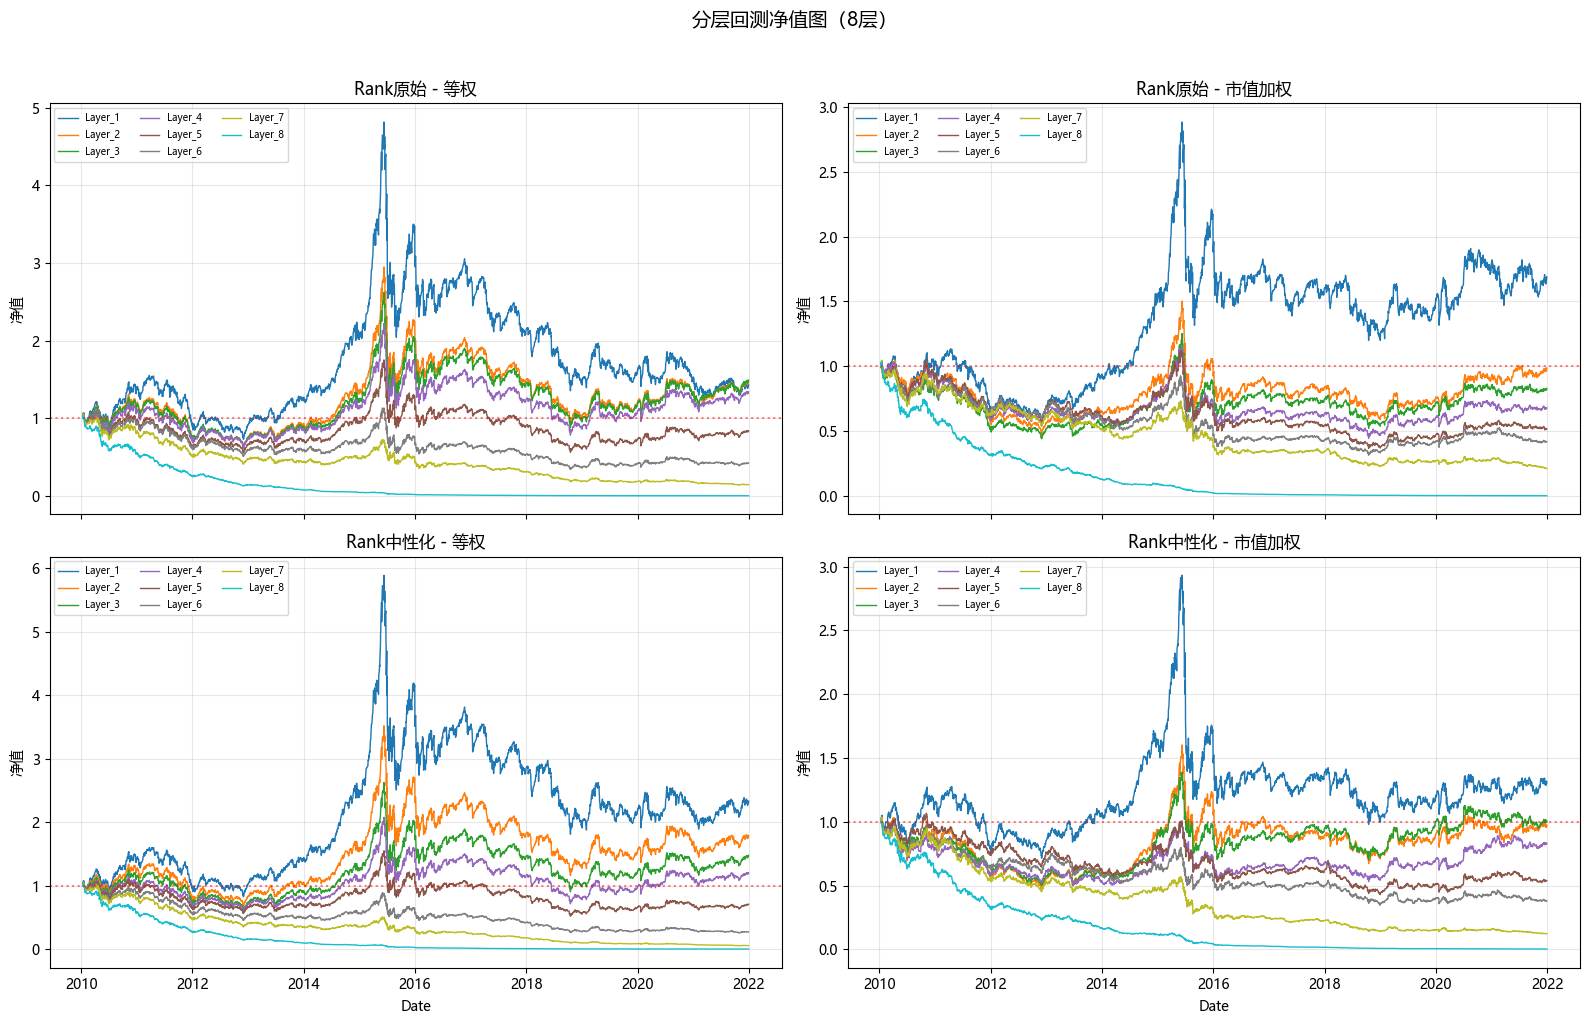

分层回测净值图已保存: stratified_backtest_8layers.png


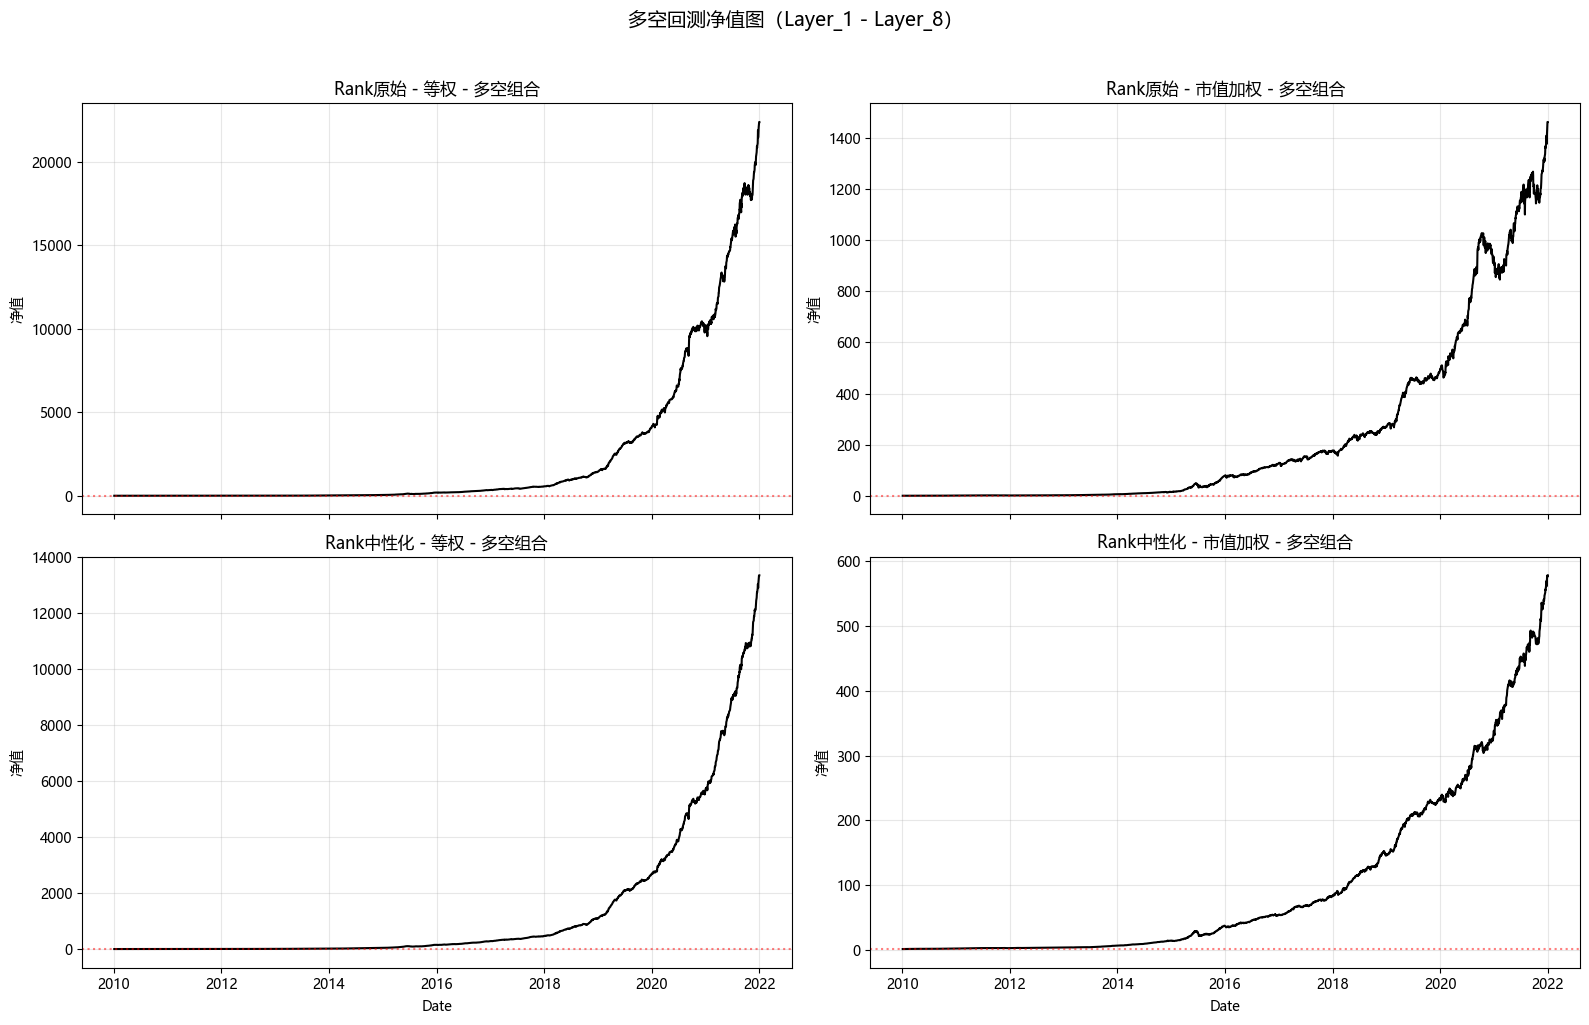

多空回测净值图已保存: long_short_backtest.png


In [11]:
# Figure 1: 分层回测净值（8层，不含多空）
fig1, axes1 = plt.subplots(2, 2, figsize=(16, 10), sharex=True)

plot_configs = [
    ('Rank原始_等权', 'Rank原始 - 等权', 0, 0),
    ('Rank原始_市值加权', 'Rank原始 - 市值加权', 0, 1),
    ('Rank中性化_等权', 'Rank中性化 - 等权', 1, 0),
    ('Rank中性化_市值加权', 'Rank中性化 - 市值加权', 1, 1),
]

colors = plt.cm.tab10(np.linspace(0, 1, 8))

for key, title, r, c in plot_configs:
    ax = axes1[r, c]
    nav = all_results[key]
    
    for i, layer_col in enumerate([f'Layer_{j}' for j in range(1, 9)]):
        if layer_col in nav.columns:
            ax.plot(nav.index, nav[layer_col], label=layer_col, color=colors[i], linewidth=1)
    
    ax.set_title(title, fontsize=12)
    ax.set_ylabel('净值')
    ax.axhline(y=1, color='red', linestyle=':', alpha=0.5)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper left', fontsize=7, ncol=3)

for ax in axes1[-1, :]:
    ax.set_xlabel('Date')

plt.suptitle('分层回测净值图（8层）', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

fig1.savefig('stratified_backtest_8layers.png', dpi=300, bbox_inches='tight')
print("分层回测净值图已保存: stratified_backtest_8layers.png")

# Figure 2: 多空回测净值（单独展示）
fig2, axes2 = plt.subplots(2, 2, figsize=(16, 10), sharex=True)

for key, title, r, c in plot_configs:
    ax = axes2[r, c]
    nav = all_results[key]
    
    if 'Long_Short' in nav.columns:
        ax.plot(nav.index, nav['Long_Short'], color='black', linewidth=1.5)
    
    ax.set_title(f'{title} - 多空组合', fontsize=12)
    ax.set_ylabel('净值')
    ax.axhline(y=1, color='red', linestyle=':', alpha=0.5)
    ax.grid(True, alpha=0.3)

for ax in axes2[-1, :]:
    ax.set_xlabel('Date')

plt.suptitle('多空回测净值图（Layer_1 - Layer_8）', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

fig2.savefig('long_short_backtest.png', dpi=300, bbox_inches='tight')
print("多空回测净值图已保存: long_short_backtest.png")


# 组合优化：二次规划选股（加分题）

正在准备数据...
共 143 个调仓日

二次规划选股执行中...
  2010-05-05: 100 stocks, top ind=14/100, max_w=3.0%
  2010-06-02: 100 stocks, top ind=17/100, max_w=3.0%
  2010-07-05: 100 stocks, top ind=14/100, max_w=3.0%
  2010-08-02: 100 stocks, top ind=14/100, max_w=3.0%
  2010-08-30: 100 stocks, top ind=14/100, max_w=3.0%
  2010-09-30: 100 stocks, top ind=17/100, max_w=3.0%
  2010-11-04: 100 stocks, top ind=20/100, max_w=3.0%
  2010-12-02: 100 stocks, top ind=20/100, max_w=3.0%
  2010-12-30: 100 stocks, top ind=14/100, max_w=3.0%
  2011-01-28: 100 stocks, top ind=20/100, max_w=3.0%
  2011-03-04: 100 stocks, top ind=14/100, max_w=3.0%
  2011-04-01: 100 stocks, top ind=14/100, max_w=3.0%
  2011-05-04: 100 stocks, top ind=11/100, max_w=3.0%
  2011-06-01: 100 stocks, top ind=20/100, max_w=3.0%
  2011-06-30: 100 stocks, top ind=20/100, max_w=3.0%
  2011-07-28: 100 stocks, top ind=16/100, max_w=3.0%
  2011-08-25: 100 stocks, top ind=17/100, max_w=3.0%
  2011-09-23: 100 stocks, top ind=20/100, max_w=3.0%
  2011-10-2

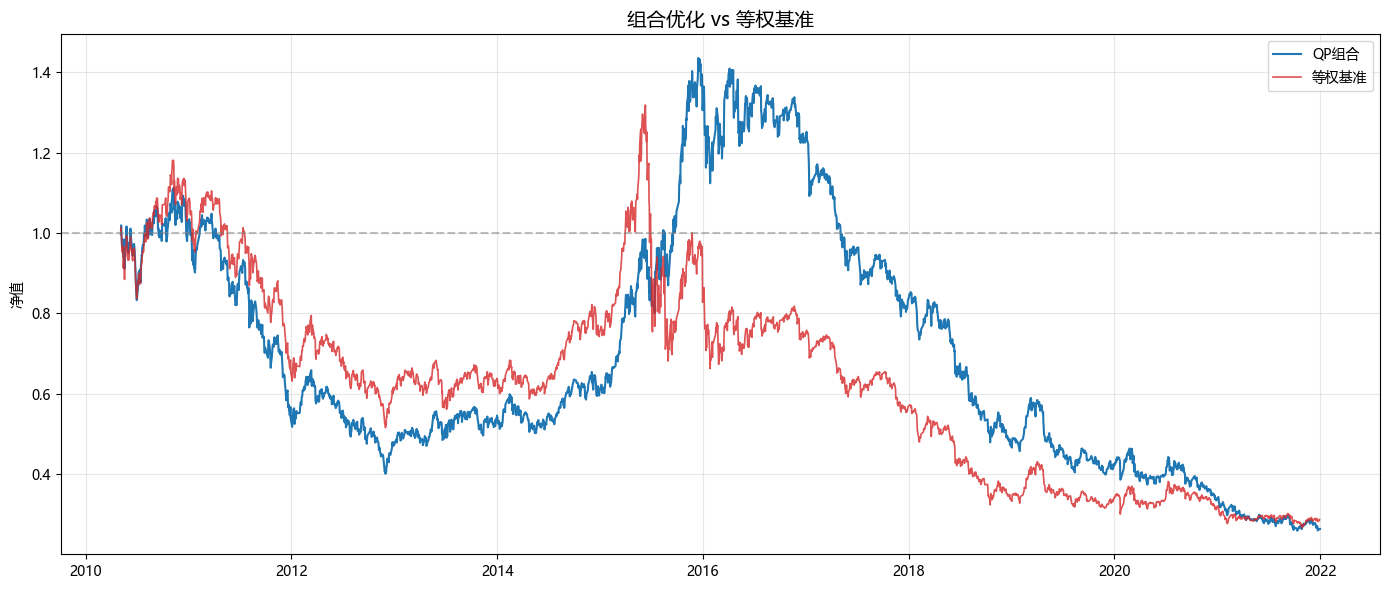

组合优化图已保存: portfolio_optimization.png


In [12]:
from scipy.optimize import minimize

# ============================================================
# 参数设置
# ============================================================
N_SELECT      = 100       # 持仓股票数
MIN_W         = 0.005     # 个股权重下限 (0.5%)
MAX_W         = 0.03      # 个股权重上限 (3%)
MAX_IND_W     = 0.20      # 行业最大暴露 (20%)
RISK_LAMBDA   = 50        # 风险厌恶系数
REBAL_FREQ    = 20        # 调仓频率（交易日）
COV_WINDOW    = 60        # 协方差估计窗口

df_reset = df.reset_index()

# ============================================================
# 1. 准备数据
# ============================================================
print("正在准备数据...")

# Alpha：IC 为负，取反号，因子值越小 → alpha 越大
df_reset['alpha'] = -df_reset['factor_rank_neu']

# 日度收益率（用于波动率估计）
df_reset['daily_ret'] = df_reset.groupby('code')['close'].transform(
    lambda x: x.pct_change()
)

# 滚动波动率（滞后一期，避免 look-ahead bias）
df_reset['roll_vol'] = (
    df_reset.groupby('code')['daily_ret']
    .transform(lambda x: x.shift(1).rolling(COV_WINDOW).std())
)

# 合并行业
if 'LEVEL1_NAME' not in df_reset.columns:
    ind = industry_data.reset_index()
    ind['DATE'] = pd.to_datetime(ind['DATE'], format='%Y%m%d')
    ind = ind.rename(columns={'CODE': 'code', 'DATE': 'date'})
    df_reset = df_reset.merge(ind[['date', 'code', 'LEVEL1_NAME']], on=['date', 'code'], how='left')

dates = sorted(df_reset['date'].unique())
rebalance_dates = dates[COV_WINDOW::REBAL_FREQ]

print(f"共 {len(rebalance_dates)} 个调仓日")

# ============================================================
# 2. 逐期选股与优化
# ============================================================
print("\n" + "=" * 60)
print("二次规划选股执行中...")
print("=" * 60)

portfolio_daily_returns = []
benchmark_daily_returns = []

for i, date in enumerate(rebalance_dates):
    # 当日所有有效股票
    day = df_reset[df_reset['date'] == date].copy()
    mask = day['alpha'].notna() & day['roll_vol'].notna() & day['LEVEL1_NAME'].notna() & (day['roll_vol'] > 0)
    valid = day[mask]
    
    if len(valid) < N_SELECT * 2:
        continue
    
    # --- Step 1: 预筛选（Alpha + 行业约束） ---
    candidates = valid.nlargest(300, 'alpha')
    selected_codes = []
    ind_count = {}
    ind_limit = max(1, int(N_SELECT * MAX_IND_W))
    
    for _, r in candidates.iterrows():
        ind = r['LEVEL1_NAME']
        if ind_count.get(ind, 0) >= ind_limit:
            continue
        selected_codes.append(r['code'])
        ind_count[ind] = ind_count.get(ind, 0) + 1
        if len(selected_codes) >= N_SELECT:
            break
    
    if len(selected_codes) < N_SELECT:
        print(f"  {date.date()}: 选股不足 ({len(selected_codes)}/{N_SELECT})，跳过")
        continue
    
    sel = day[day['code'].isin(selected_codes)].set_index('code').loc[selected_codes].reset_index()
    
    alpha_vec   = sel['alpha'].values
    vol_vec     = sel['roll_vol'].values
    code_vec    = sel['code'].values
    ind_vec     = sel['LEVEL1_NAME'].values
    n           = len(code_vec)
    
    # --- Step 2: 二次规划 ---
    D = np.diag(vol_vec ** 2)  # 对角协方差矩阵
    
    def objective(w):
        return -np.dot(alpha_vec, w) + RISK_LAMBDA * np.dot(w, np.dot(D, w))
    
    # 约束：权重和为 1
    cons = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]
    
    # 约束：行业暴露 ≤ MAX_IND_W
    for ind in pd.unique(ind_vec):
        ind_mask = (ind_vec == ind).astype(float)
        cons.append({
            'type': 'ineq',
            'fun': lambda w, m=ind_mask: MAX_IND_W - np.dot(m, w)
        })
    
    bounds = [(MIN_W, MAX_W)] * n
    w0 = np.ones(n) / n
    
    try:
        res = minimize(
            objective, w0, method='SLSQP',
            bounds=bounds, constraints=cons,
            options={'maxiter': 500, 'ftol': 1e-10}
        )
    except Exception as e:
        print(f"  {date.date()}: 优化报错 - {e}")
        continue
    
    if not res.success:
        print(f"  {date.date()}: 未收敛，跳过")
        continue
    
    w_opt = res.x
    w_opt[w_opt < MIN_W * 0.8] = 0
    w_opt = w_opt / w_opt.sum()
    
    # --- Step 3: 计算持有期收益 ---
    end_idx = dates.index(date) + REBAL_FREQ
    end_date = dates[min(end_idx, len(dates) - 1)]
    
    period = df_reset[
        (df_reset['date'] > date) & 
        (df_reset['date'] <= end_date)
    ].copy()
    
    weight_map = dict(zip(code_vec, w_opt))
    period['weight'] = period['code'].map(weight_map).fillna(0)
    period['w_ret']  = period['return'].fillna(0) * period['weight']
    
    port_daily = period.groupby('date')['w_ret'].sum()
    portfolio_daily_returns.append(port_daily)
    
    # 等权基准
    bench_data = period[period['return'].notna()]
    bench_daily = bench_data.groupby('date')['return'].mean()
    benchmark_daily_returns.append(bench_daily)
    
    active_n = (w_opt > 0).sum()
    print(f"  {date.date()}: {active_n} stocks, "
          f"top ind={ind_count[max(ind_count, key=ind_count.get)]}/{N_SELECT}, "
          f"max_w={w_opt.max()*100:.1f}%")

# ============================================================
# 3. 绩效汇总
# ============================================================
if portfolio_daily_returns:
    port_ret_all = pd.concat(portfolio_daily_returns).sort_index()
    bench_ret_all = pd.concat(benchmark_daily_returns).sort_index()
    
    port_nav = (1 + port_ret_all).cumprod()
    bench_nav = (1 + bench_ret_all).cumprod()
    
    # 指标
    def eval_nav(nav_series):
        rets = nav_series.pct_change(fill_method=None).dropna()
        ann_ret = (nav_series.iloc[-1] / nav_series.iloc[0]) ** (252 / len(nav_series)) - 1
        ann_vol = rets.std() * np.sqrt(252)
        sharpe  = ann_ret / ann_vol if ann_vol > 0 else np.nan
        dd      = (1 - nav_series / nav_series.cummax()).max()
        return ann_ret, ann_vol, sharpe, dd
    
    p_ret, p_vol, p_sharpe, p_dd = eval_nav(port_nav)
    b_ret, b_vol, b_sharpe, b_dd = eval_nav(bench_nav)
    
    print("\n" + "=" * 60)
    print("组合优化绩效对比")
    print("=" * 60)
    print(f"{'':>12s}  {'QP组合':>10s}  {'等权基准':>10s}")
    print(f"{'年化收益':>12s}: {p_ret:>9.2%}  {b_ret:>9.2%}")
    print(f"{'年化波动':>12s}: {p_vol:>9.2%}  {b_vol:>9.2%}")
    print(f"{'夏普比率':>12s}: {p_sharpe:>9.2f}  {b_sharpe:>9.2f}")
    print(f"{'最大回撤':>12s}: {p_dd:>9.2%}  {b_dd:>9.2%}")
    
    # 画图
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.plot(port_nav.index, port_nav.values, label='QP组合', linewidth=1.5, color='#1f77b4')
    ax.plot(bench_nav.index, bench_nav.values, label='等权基准', linewidth=1.2, color='#d62728', alpha=0.8)
    ax.axhline(y=1, color='gray', linestyle='--', alpha=0.5)
    ax.set_title('组合优化 vs 等权基准', fontsize=14)
    ax.set_ylabel('净值')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    fig.savefig('portfolio_optimization.png', dpi=300, bbox_inches='tight')
    print("组合优化图已保存: portfolio_optimization.png")
else:
    print("未生成有效组合，请检查参数或数据。")
